<a href="https://colab.research.google.com/github/lakshyaagrawal709-collab/airbnb-price-analysis/blob/main/01_eda_and_cleaning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# Airbnb Dynamic Pricing Analysis
**Submitted by:** lakshay Agrawal N243

## 1. Problem Statement
Many Airbnb hosts struggle to set competitive prices, which leads to lost bookings. This project analyzes the local context to help hosts optimize pricing.


In [7]:
import pandas as pd
import os

# 1. Load the dataset (Extract)
file_path = '/content/drive/MyDrive/airbnb-price-analysis/Data/raw/airbnbsg.csv.csv'
df = pd.read_csv(file_path)

print("--- DATA QUALITY REPORT (BEFORE CLEANING) ---")
print(f"Total Rows: {len(df)}")
print(f"Missing Values:\n{df.isnull().sum()}\n")

# 2. Handle missing values
# Replace empty reviews with 0 (logical fix instead of deleting data)
df['reviews_per_month'] = df['reviews_per_month'].fillna(0)
df['name'] = df['name'].fillna("Unknown")

# 3. Remove unnecessary columns to speed up processing
df = df.drop(['last_review'], axis=1)

# 4. Remove exact duplicates
df = df.drop_duplicates()

print("--- DATA QUALITY REPORT (AFTER CLEANING) ---")
print(f"Total Rows Remaining: {len(df)}")
print(f"Missing Values Left:\n{df.isnull().sum()}\n")

# Save the clean data
save_dir = '/content/drive/MyDrive/airbnb-price-analysis/Data/processed'
os.makedirs(save_dir, exist_ok=True)
clean_path = f'{save_dir}/clean_airbnbsg.csv'
df.to_csv(clean_path, index=False)

--- DATA QUALITY REPORT (BEFORE CLEANING) ---
Total Rows: 7907
Missing Values:
id                                   0
name                                 2
host_id                              0
host_name                            0
neighbourhood_group                  0
neighbourhood                        0
latitude                             0
longitude                            0
room_type                            0
price                                0
minimum_nights                       0
number_of_reviews                    0
last_review                       2758
reviews_per_month                 2758
calculated_host_listings_count       0
availability_365                     0
dtype: int64

--- DATA QUALITY REPORT (AFTER CLEANING) ---
Total Rows Remaining: 7907
Missing Values Left:
id                                0
name                              0
host_id                           0
host_name                         0
neighbourhood_group               0
neighbourh

--- STATISTICAL SUMMARY ---
              price  minimum_nights  number_of_reviews
count   7907.000000     7907.000000        7907.000000
mean     169.332996       17.510054          12.807386
std      340.187599       42.094616          29.707746
min        0.000000        1.000000           0.000000
25%       65.000000        1.000000           0.000000
50%      124.000000        3.000000           2.000000
75%      199.000000       10.000000          10.000000
max    10000.000000     1000.000000         323.000000


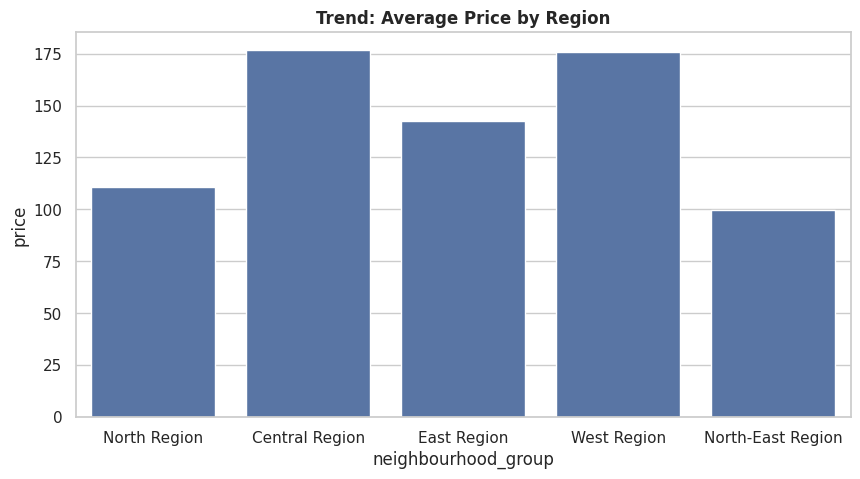

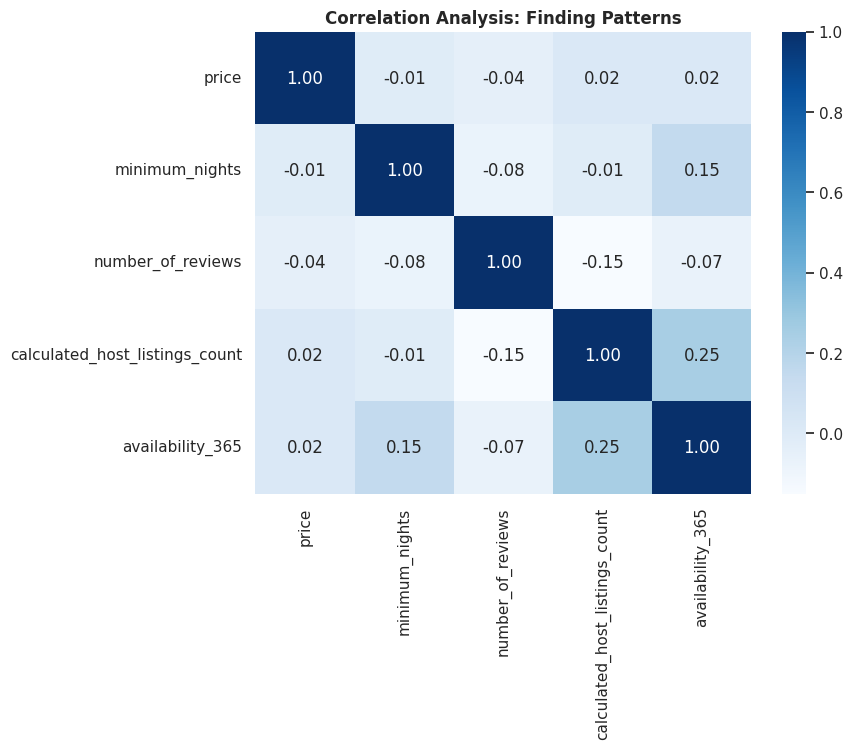

In [8]:
import seaborn as sns
import matplotlib.pyplot as plt

# Load clean data
df_clean = pd.read_csv(clean_path)

# 1. Statistical Summary
print("--- STATISTICAL SUMMARY ---")
print(df_clean[['price', 'minimum_nights', 'number_of_reviews']].describe())

# 2. Trend Identification (Bar Chart)
plt.figure(figsize=(10, 5))
sns.barplot(x='neighbourhood_group', y='price', data=df_clean, errorbar=None)
plt.title('Trend: Average Price by Region', fontweight='bold')
plt.show()

# 3. Correlation Analysis (Heatmap)
# Selecting only numbers to see what drives the price up or down
numerical_data = df_clean[['price', 'minimum_nights', 'number_of_reviews', 'calculated_host_listings_count', 'availability_365']]

plt.figure(figsize=(8, 6))
sns.heatmap(numerical_data.corr(), annot=True, cmap='Blues', fmt=".2f")
plt.title('Correlation Analysis: Finding Patterns', fontweight='bold')
plt.show()

In [9]:
from sklearn.model_selection import cross_val_score, train_test_split
from sklearn.ensemble import RandomForestRegressor
import numpy as np

# 1. Feature Engineering
# Convert text categories (like Region or Room Type) into machine-readable numbers
df_model = df_clean[['neighbourhood_group', 'room_type', 'minimum_nights', 'number_of_reviews', 'price']].copy()
df_model = pd.get_dummies(df_model, columns=['neighbourhood_group', 'room_type'], drop_first=True)

# Define our features (X) and our target price (y)
X = df_model.drop('price', axis=1)
y = df_model['price']

# 2. Model Selection
# Random Forest is highly accurate for real estate/pricing data
rf_model = RandomForestRegressor(n_estimators=50, random_state=42)

# 3. Cross-Validation & Performance Metrics
# Testing the model on 5 different chunks of data to ensure it is reliable
cv_scores = cross_val_score(rf_model, X, y, cv=5, scoring='neg_mean_squared_error')
rmse_scores = np.sqrt(-cv_scores)

print("--- MODEL PERFORMANCE METRICS ---")
print(f"Cross-Validation RMSE Scores: {rmse_scores}")
print(f"Average Error Margin (RMSE): ${rmse_scores.mean():.2f}")

--- MODEL PERFORMANCE METRICS ---
Cross-Validation RMSE Scores: [405.0868704  505.82322093 292.93106338 335.86715689 272.89411143]
Average Error Margin (RMSE): $362.52
